In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train_df= pd.read_csv("/content/train_u6lujuX_CVtuZ9i.csv")
test_df = pd.read_csv("/content/test_Y3wMUE5_7gLdaTN.csv")

In [4]:
print("Train data shape:",train_df.shape)
print("Test data shape:",test_df.shape)

Train data shape: (614, 13)
Test data shape: (367, 12)


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [8]:
train_df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [9]:
train_df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [10]:
train_df['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


HANDLING MISSING VALUES

In [14]:
#Since the missing values are less, we fill them instead of deleting them
#For all the categorical values, lets fill them using mode

train_df['Gender']= train_df['Gender'].fillna(train_df['Gender'].mode()[0])
train_df['Married']= train_df['Married'].fillna(train_df['Married'].mode()[0])
train_df['Dependents']= train_df['Dependents'].fillna(train_df['Dependents'].mode()[0])
train_df["Self_Employed"] = train_df["Self_Employed"].fillna(train_df["Self_Employed"].mode()[0])


In [15]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


HANDLING NUMERICAL COLUMNS:

In [16]:
train_df['LoanAmount']= train_df['LoanAmount'].fillna(train_df['LoanAmount'].median())

In [17]:
train_df['Loan_Amount_Term']= train_df['Loan_Amount_Term'].fillna(train_df['Loan_Amount_Term'].mode()[0])

In [18]:
train_df["Credit_History"] = train_df["Credit_History"].fillna(train_df["Credit_History"].mode()[0])

In [19]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [20]:
train_df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [24]:
test_df.isnull().sum()

,0
Loan_ID,0
Gender,11
Married,0
Dependents,10
Education,0
Self_Employed,23
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,5
Loan_Amount_Term,6


In [27]:
test_df['Gender']= test_df['Gender'].fillna(test_df['Gender'].mode()[0])
test_df['Dependents']= test_df['Dependents'].fillna(test_df['Dependents'].mode()[0])
test_df["Self_Employed"] = test_df["Self_Employed"].fillna(test_df["Self_Employed"].mode()[0])
test_df["LoanAmount"] = test_df["LoanAmount"].fillna(test_df["LoanAmount"].median())
test_df["Loan_Amount_Term"] = test_df["Loan_Amount_Term"].fillna(test_df["Loan_Amount_Term"].mode()[0])
test_df["Credit_History"] = test_df["Credit_History"].fillna(test_df["Credit_History"].mode()[0])

In [28]:
test_df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
FEATURE ENGINEERING

In [33]:
x=train_df.drop(columns=["Loan_ID","Loan_Status"])
y=train_df["Loan_Status"]

In [34]:
#convert the categorical Loan_status column to 1 or 0
y=y.map({"Y":1,"N":0})
y.value_counts()

,count
Loan_Status,
1,422
0,192


In [37]:
#Convert categorical features into numeric using one-hot encoding
x = pd.get_dummies(x, drop_first=True, dtype=int)
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ApplicantIncome          614 non-null    int64  
 1   CoapplicantIncome        614 non-null    float64
 2   LoanAmount               614 non-null    float64
 3   Loan_Amount_Term         614 non-null    float64
 4   Credit_History           614 non-null    float64
 5   Gender_Male              614 non-null    int64  
 6   Married_Yes              614 non-null    int64  
 7   Dependents_1             614 non-null    int64  
 8   Dependents_2             614 non-null    int64  
 9   Dependents_3+            614 non-null    int64  
 10  Education_Not Graduate   614 non-null    int64  
 11  Self_Employed_Yes        614 non-null    int64  
 12  Property_Area_Semiurban  614 non-null    int64  
 13  Property_Area_Urban      614 non-null    int64  
dtypes: float64(4), int64(10)
m

In [41]:
x.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Gender_Male', 'Married_Yes',
       'Dependents_1', 'Dependents_2', 'Dependents_3+',
       'Education_Not Graduate', 'Self_Employed_Yes',
       'Property_Area_Semiurban', 'Property_Area_Urban'],
      dtype='object')

In [43]:
#split the data into test train

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.20, random_state=42, stratify=y)

#test_size=0.20 keeps 20% of the data for model evaluation.
#random_state=42 ensures you get the same split every time you run the notebook.
#stratify=y keeps a similar proportion of approved and rejected loans in both the training and testing sets.

In [45]:
print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)


x_train shape: (491, 14)
x_test shape: (123, 14)
y_train shape: (491,)
y_test shape: (123,)


BUILDING THE 3 CLASSIFICATION MODELS

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score

In [49]:
# Logistic Regression
logistic_model = Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(max_iter=1000))])

# Decision Tree
decision_tree_model = DecisionTreeClassifier(max_depth=4,random_state=42)

# K-Nearest Neighbors
knn_model = Pipeline([("scaler", StandardScaler()),("model", KNeighborsClassifier(n_neighbors=5))])

#scaling is needed to bring all the numerical features into one scale.
#Specially KNN is performed using clculating the distand, hence all the values needs to be in one scale

In [51]:
#Train the models

logistic_model.fit(x_train,y_train)
decision_tree_model.fit(x_train,y_train)
knn_model.fit(x_train,y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])

In [52]:
#Make preidctions
logistic_predictions = logistic_model.predict(x_test)

decision_tree_predictions = decision_tree_model.predict(x_test)

knn_predictions = knn_model.predict(x_test)

In [53]:
print("Logistic Regression:", logistic_predictions[:10])
print("Decision Tree:", decision_tree_predictions[:10])
print("KNN:", knn_predictions[:10])

Logistic Regression: [0 1 1 1 1 1 1 1 1 1]
Decision Tree: [0 1 1 1 1 1 1 1 1 1]
KNN: [0 1 1 1 1 1 1 1 1 1]


MODEL EVALUATION

In [55]:
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)

print("Logistic Regression")
print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)
print("F1-score:", logistic_f1)

Logistic Regression
Accuracy: 0.8617886178861789
Precision: 0.84
Recall: 0.9882352941176471
F1-score: 0.9081081081081082


In [56]:
tree_accuracy = accuracy_score(y_test, decision_tree_predictions)
tree_precision = precision_score(y_test, decision_tree_predictions)
tree_recall = recall_score(y_test, decision_tree_predictions)
tree_f1 = f1_score(y_test, decision_tree_predictions)

print("Decision Tree")
print("Accuracy:", tree_accuracy)
print("Precision:", tree_precision)
print("Recall:", tree_recall)
print("F1-score:", tree_f1)

Decision Tree
Accuracy: 0.8455284552845529
Precision: 0.8235294117647058
Recall: 0.9882352941176471
F1-score: 0.8983957219251337


In [57]:
knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_precision = precision_score(y_test, knn_predictions)
knn_recall = recall_score(y_test, knn_predictions)
knn_f1 = f1_score(y_test, knn_predictions)

print("KNN")
print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1-score:", knn_f1)

KNN
Accuracy: 0.8373983739837398
Precision: 0.8282828282828283
Recall: 0.9647058823529412
F1-score: 0.8913043478260869


In [58]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","KNN"],
    "Accuracy": [logistic_accuracy,tree_accuracy,knn_accuracy],
    "Precision": [logistic_precision,tree_precision,knn_precision],
    "Recall": [logistic_recall,tree_recall,knn_recall],
    "F1-score": [logistic_f1,tree_f1,knn_f1]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.861789,0.840000,0.988235,0.908108
1,Decision Tree,0.845528,0.823529,0.988235,0.898396
2,KNN,0.837398,0.828283,0.964706,0.891304


LOGISTIC REGRESSION PERFORMS BEST AMOUNG ALL OTHERS

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

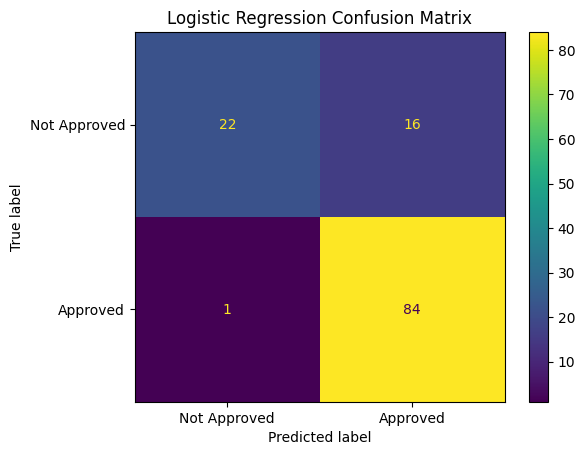

In [60]:
cm_logistic = confusion_matrix(y_test, logistic_predictions)

ConfusionMatrixDisplay(confusion_matrix=cm_logistic,display_labels=["Not Approved", "Approved"]).plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

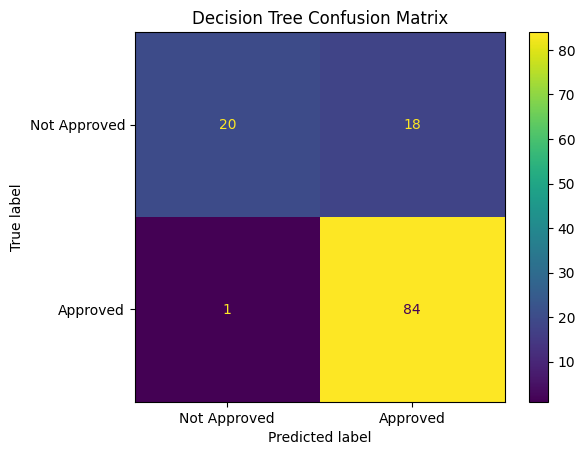

In [61]:
cm_tree = confusion_matrix(y_test, decision_tree_predictions)

ConfusionMatrixDisplay(confusion_matrix=cm_tree,display_labels=["Not Approved", "Approved"]).plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()

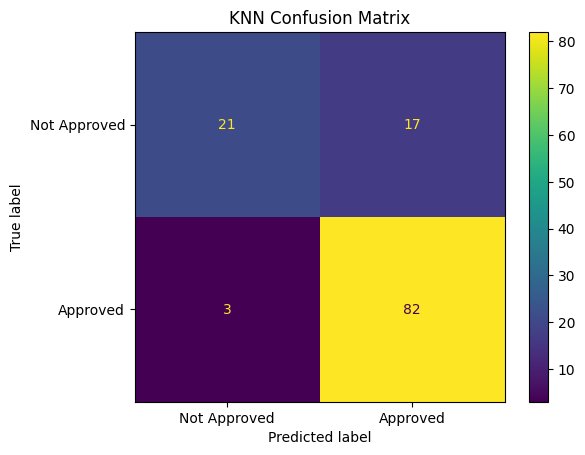

In [62]:
cm_knn = confusion_matrix(y_test, knn_predictions)

ConfusionMatrixDisplay(confusion_matrix=cm_knn,display_labels=["Not Approved", "Approved"]).plot()

plt.title("KNN Confusion Matrix")
plt.show()

BASED ON ALL METRICS, THE BEST PERFORIMING MODEL IS LOGISTIC REGRESSION